# ECOv003 JET Accuracy Analysis with ECOv002 Cal-Val with SHAP Sensitivity

This notebook performs a sensitivity analysis of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data[cite: 1]. It utilizes SHAP (SHapley Additive exPlanations) and a Random Forest surrogate model to naturally account for collinearity (e.g., between surface and air temperature) without generating physically impossible parameter combinations.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting[cite: 1]. It includes custom modules for the JET ensemble, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries and the newly added SHAP libraries.

In [13]:
import sys
import os
import contextlib
import warnings
import math
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy.stats import mstats
from sklearn.metrics import r2_score, mean_squared_error

# Machine Learning and Sensitivity Libraries
import shap
from sklearn.ensemble import RandomForestRegressor

# Custom JET modules
from verma_net_radiation import verma_net_radiation_table
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs

## Configuration Options

Set configuration options for the notebook, including whether to save plots to files[cite: 1].

In [14]:
# Configuration: Set to True to save plots to files, False to only display them
SAVE_PLOTS = False

In [15]:
input_variables = [
    "ST_C",
    "NDVI",
    "albedo",
    "Ta_C",
    "RH",
    "AOT",
    "COT",
    "vapor_gccm",
    "ozone_cm",
    "elevation_m",
    "canopy_height_meters"
]

output_variables = [
    "Rn_Wm2",
    "ET_daylight_kg",
    "GPP_inst_g_m2_s"
]

# Per-variable physical bounds to keep perturbations realistic
input_min = {
    "ST_C": 0.0,
    "NDVI": 0.05,
    "albedo": 0.0,
    "Ta_C": 0.0,
    "RH": 0.0,
    "AOT": 0.0,
    "COT": 0.0,
    "vapor_gccm": 0.0,
    "ozone_cm": 0.0,
    "elevation_m": 0.0,
    "canopy_height_meters": 0.0
}

input_max = {
    "ST_C": 50.0,
    "NDVI": 1,
    "albedo": 1
}

## Define Processing Function for Model Table

This cell defines the forward process for analysis as the BESS-JPL model[cite: 1].

In [16]:
forward_process = process_JET_table
model_name = "JET"

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out surface temperatures greater than 50 Celsius and NDVI values less than 0.05[cite: 1]. The resulting DataFrame is displayed for inspection.

In [17]:
input_df = load_ECOv002_calval_JET_inputs()

# Apply lower and upper bounds from configuration dictionaries
mask = pd.Series(True, index=input_df.index)
for var, min_val in input_min.items():
    if var in input_df.columns:
        mask &= input_df[var] >= min_val
for var, max_val in input_max.items():
    if var in input_df.columns:
        mask &= input_df[var] <= max_val

input_df = input_df[mask]
input_df = input_df.dropna()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,CL,Tmin_open,Tmin_closed,VPD_open,VPD_closed,Tmin_C,Topt_C,fAPARmax,field_capacity,wilting_point
15,15,US-xAB,ENF,Csb,141.635670,168.24043,402.81810,159.71700,139.016083,107.183200,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
17,17,US-xAB,ENF,Csb,1.881266,163.94730,301.40400,179.13661,131.273636,106.525215,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
18,18,US-xAB,ENF,Csb,3.135606,246.87700,614.51480,405.50497,366.056641,222.890230,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
19,19,US-xAB,ENF,Csb,311.482820,290.73126,672.27510,478.82382,439.821228,153.787670,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
20,20,US-xAB,ENF,Csb,51.920338,95.28810,116.67136,73.20884,232.693512,24.038680,...,0.0032,8.31,-8.0,650.0,3000.0,11.940895,6.69,0.6040,0.33,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,992,US-xML,DBF,Dfb,417.831120,706.93066,523.92740,310.69684,356.174072,148.624050,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
994,994,US-xML,DBF,Dfb,161.558200,306.15277,420.44678,206.48576,237.659103,98.727560,...,0.0065,11.39,-8.0,650.0,3500.0,27.538052,2.66,0.5404,0.34,0.14
1001,1001,US-UiB,CRO,Dfa,93.876100,251.38747,238.71077,198.90399,106.316444,67.694800,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,2.58,0.4060,0.32,0.14
1020,1020,US-ARM,CRO,Cfa,80.255005,0.00000,180.10085,211.28325,164.581390,84.672410,...,0.0070,12.02,-8.0,650.0,4500.0,9.637029,8.48,0.4017,0.29,0.12


## SHAP Sensitivity Functions

Defining the Random Forest surrogate and SHAP beeswarm plot functions to accurately evaluate interdependent variables.

In [18]:
def SHAP_sensitivity_analysis(
    input_df, 
    input_variables, 
    target_output, 
    forward_process, 
    custom_bounds=None,
    N=1024, 
    theme_name="whitegrid", 
    palette_name="viridis"
):
    # 1. Clean the input table
    input_df_clean = input_df.dropna(subset=[var for var in input_variables if var in input_df.columns]).copy()
    
    if custom_bounds:
        for var, bounds in custom_bounds.items():
            if var in input_df_clean.columns:
                input_df_clean = input_df_clean[
                    (input_df_clean[var] >= bounds[0]) & 
                    (input_df_clean[var] <= bounds[1])
                ]
    
    # 2. Sample directly from the dataset (Preserves real-world collinearity)
    sample_size = min(N, len(input_df_clean))
    samples_df = input_df_clean.sample(n=sample_size, random_state=42).copy()
    X = samples_df[input_variables]
    
    # 3. Execute the forward run with suppressed console output
    print(f"Executing forward process for {len(samples_df)} empirical samples...")
    with open(os.devnull, 'w') as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            processed_samples = forward_process(samples_df)
            
    print("Forward process complete.")
    
    # 4. Extract target output and handle NaNs safely
    Y = processed_samples[target_output].values
    if np.isnan(Y).any():
        nan_count = np.isnan(Y).sum()
        warnings.warn(f"\nWarning: {nan_count} NaN values detected in output. Replacing with mean.")
        valid_mean = np.nanmean(Y)
        Y = np.nan_to_num(Y, nan=valid_mean)
        
    # 5. Train the Surrogate Model
    print("Training Random Forest surrogate model...")
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X, Y)
    
    # Check surrogate accuracy
    r2_score_val = model.score(X, Y)
    print(f"Surrogate Model R^2: {r2_score_val:.3f}")
    if r2_score_val < 0.7:
        warnings.warn("Surrogate R^2 is low. SHAP values may not accurately represent the physical model.")
    
    # 6. Calculate SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    # Calculate Mean Absolute SHAP (Global Importance)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    # Sort for plotting
    sort_indices = np.argsort(mean_abs_shap)[::-1]
    sorted_vars = [input_variables[i] for i in sort_indices]
    sorted_shap = mean_abs_shap[sort_indices]
    
    # 7. Visualize Global SHAP Importance (The Bar Chart Equivalent)
    sns.set_theme(style=theme_name)
    colors = sns.color_palette(palette_name, n_colors=len(input_variables))
    
    fig, ax = plt.subplots(figsize=(10, 8))
    x_pos = np.arange(len(sorted_vars))
    
    ax.bar(x_pos, sorted_shap, color=colors[0], edgecolor="white", linewidth=1)
    
    ax.set_ylabel(f'Mean |SHAP| (Impact on {target_output})', fontsize=12, weight='bold')
    ax.set_title(f'SHAP Global Sensitivity for {target_output}', fontsize=15, weight='bold', pad=15)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(sorted_vars, rotation=45, ha='right', fontsize=11)
    
    sns.despine(left=True)
    ax.grid(axis='y', linestyle='-', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return explainer, shap_values, X

def SHAP_scatter_analysis(explainer, shap_values, X, target_output):
    print("Generating SHAP beeswarm plot...")
    plt.style.use('default')
    plt.figure(figsize=(10, 6))
    
    shap.summary_plot(
        shap_values, 
        X, 
        plot_type="dot", 
        show=False, 
        cmap="coolwarm"
    )
    
    plt.title(f'SHAP Beeswarm Summary for {target_output}', fontsize=15, weight='bold', pad=15)
    plt.xlabel(f'SHAP Value (Impact on {target_output})', fontsize=12, weight='bold')
    
    plt.tight_layout()
    plt.show()


## Execute Global Sensitivity and Beeswarm Analysis

Run the SHAP sensitivity analysis on the target output `ET_daylight_kg`.

Executing forward process for 270 empirical samples...
[2026-08-10 15:11:15 INFO] starting JET table processing
[2026-08-10 15:11:15 INFO] started extracting geometry from JET input table
[2026-08-10 15:11:15 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-10 15:11:15 INFO] started extracting time from JET input table
[2026-08-10 15:11:15 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-10 15:11:15 INFO] running Forest Light Environmental Simulator
[2026-08-10 15:11:15 INFO] completed processing FLiES-ANN in 0.22 seconds
[2026-08-10 15:11:15 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-10 15:11:15 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-10 15:11:15 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-10 15:11:15 INFO] variable SWin_FLiES_ANN min: 163.676 mean: 716.916 max: 1095.605 nan: 0.00% (nan)

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

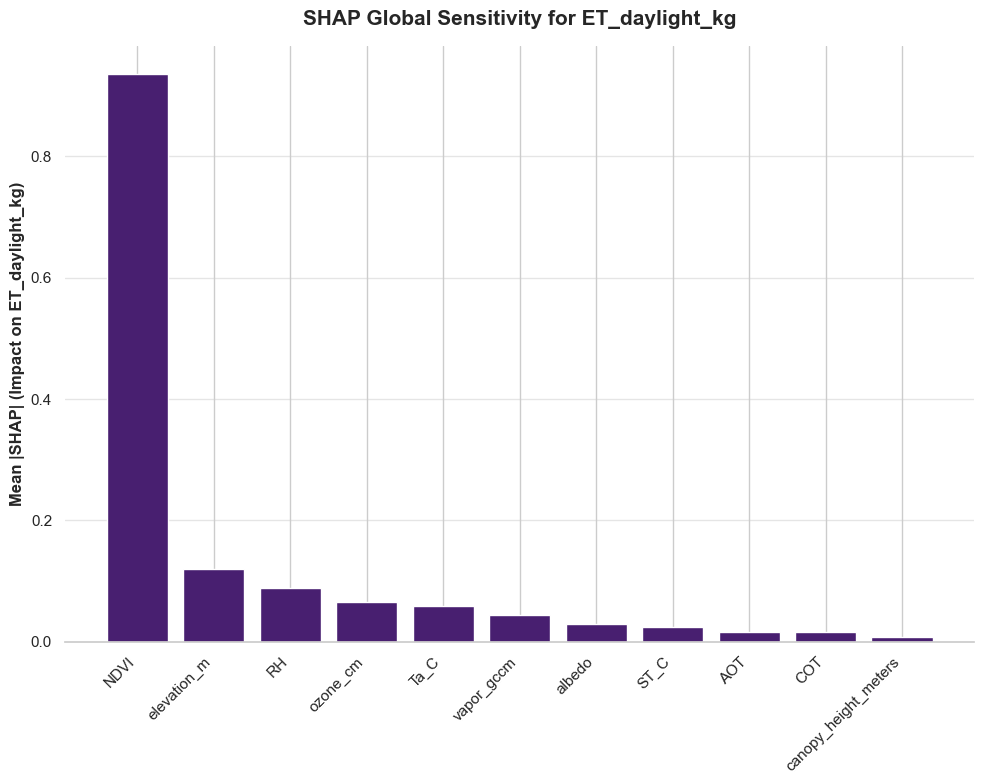

Generating SHAP beeswarm plot...


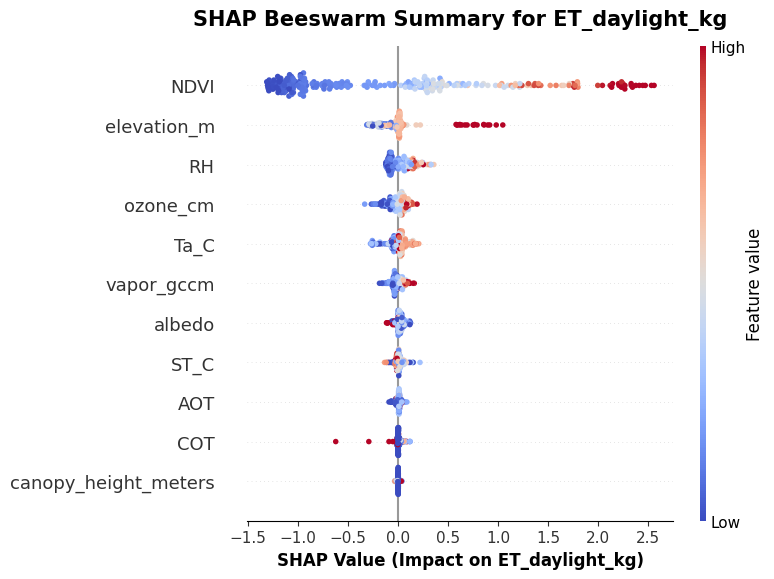

In [19]:
target_output = "ET_daylight_kg"

explainer, shap_values, X = SHAP_sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    target_output=target_output,
    forward_process=forward_process,
    N=1024
)

SHAP_scatter_analysis(
    explainer=explainer,
    shap_values=shap_values,
    X=X,
    target_output=target_output
)


Running SHAP Sensitivity Analysis for: LE_BESS_Wm2

Executing forward process for 270 empirical samples...
[2026-08-10 15:11:16 INFO] starting JET table processing
[2026-08-10 15:11:16 INFO] started extracting geometry from JET input table
[2026-08-10 15:11:16 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-10 15:11:16 INFO] started extracting time from JET input table
[2026-08-10 15:11:16 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-10 15:11:16 INFO] running Forest Light Environmental Simulator
[2026-08-10 15:11:16 INFO] completed processing FLiES-ANN in 0.18 seconds
[2026-08-10 15:11:16 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-10 15:11:16 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-10 15:11:16 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-10 15:11:16 INFO] variable SWin_FLiES_ANN min:

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

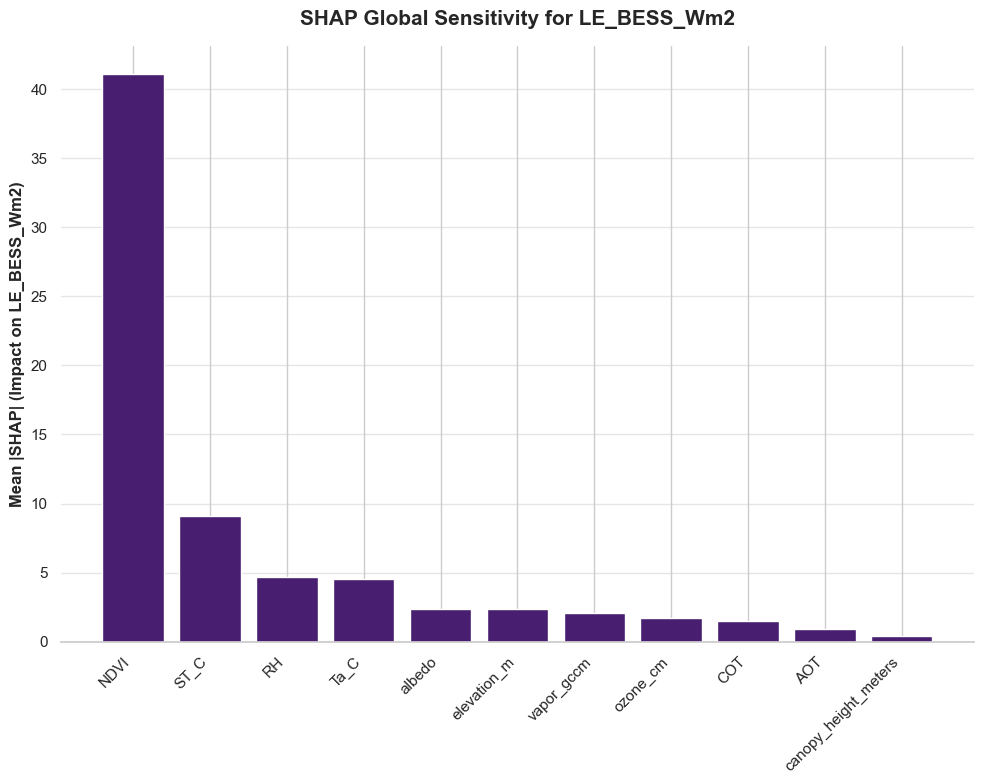

Generating SHAP beeswarm plot...


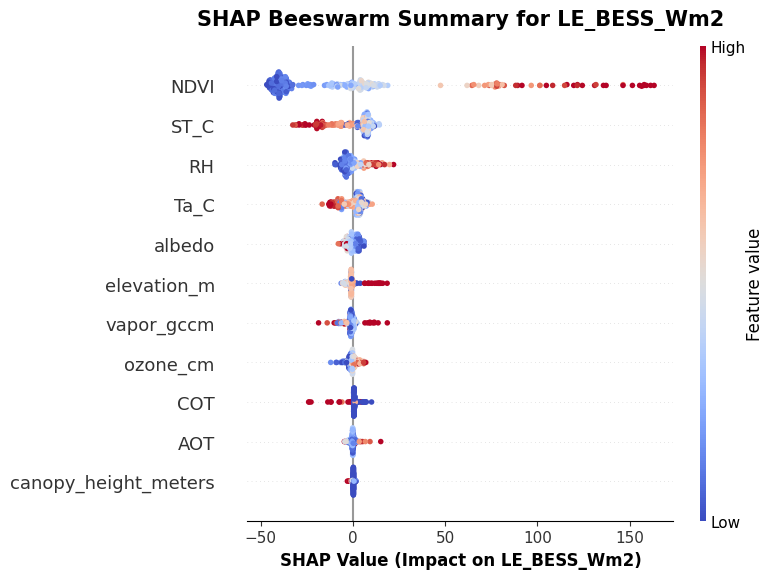


Running SHAP Sensitivity Analysis for: LE_STIC_Wm2

Executing forward process for 270 empirical samples...
[2026-08-10 15:11:17 INFO] starting JET table processing
[2026-08-10 15:11:17 INFO] started extracting geometry from JET input table
[2026-08-10 15:11:17 INFO] completed extracting geometry from JET input table (0.005 seconds)
[2026-08-10 15:11:17 INFO] started extracting time from JET input table
[2026-08-10 15:11:17 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-10 15:11:17 INFO] running Forest Light Environmental Simulator
[2026-08-10 15:11:17 INFO] completed processing FLiES-ANN in 0.21 seconds
[2026-08-10 15:11:17 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-10 15:11:17 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-10 15:11:17 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-10 15:11:17 INFO] variable SWin_FLiES_ANN min:

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

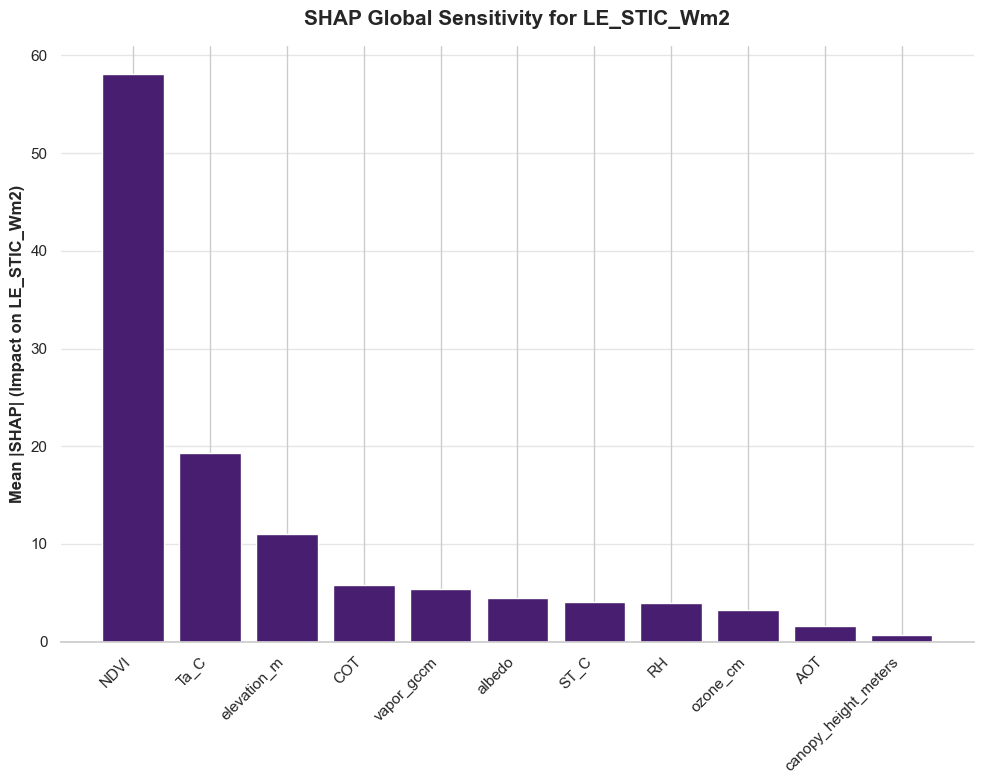

Generating SHAP beeswarm plot...


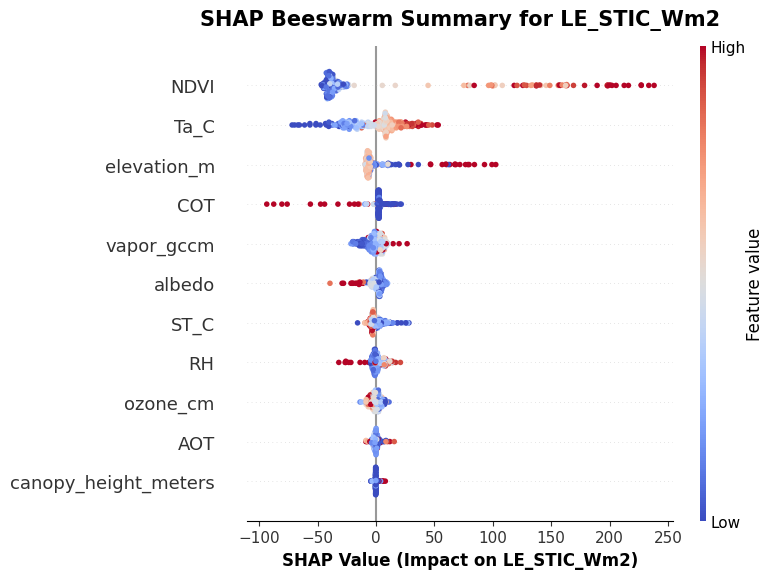


Running SHAP Sensitivity Analysis for: LE_PTJPLSM_Wm2

Executing forward process for 270 empirical samples...
[2026-08-10 15:11:18 INFO] starting JET table processing
[2026-08-10 15:11:18 INFO] started extracting geometry from JET input table
[2026-08-10 15:11:18 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-10 15:11:18 INFO] started extracting time from JET input table
[2026-08-10 15:11:18 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-10 15:11:18 INFO] running Forest Light Environmental Simulator
[2026-08-10 15:11:18 INFO] completed processing FLiES-ANN in 0.19 seconds
[2026-08-10 15:11:18 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-10 15:11:18 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-10 15:11:18 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-10 15:11:18 INFO] variable SWin_FLiES_ANN m

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

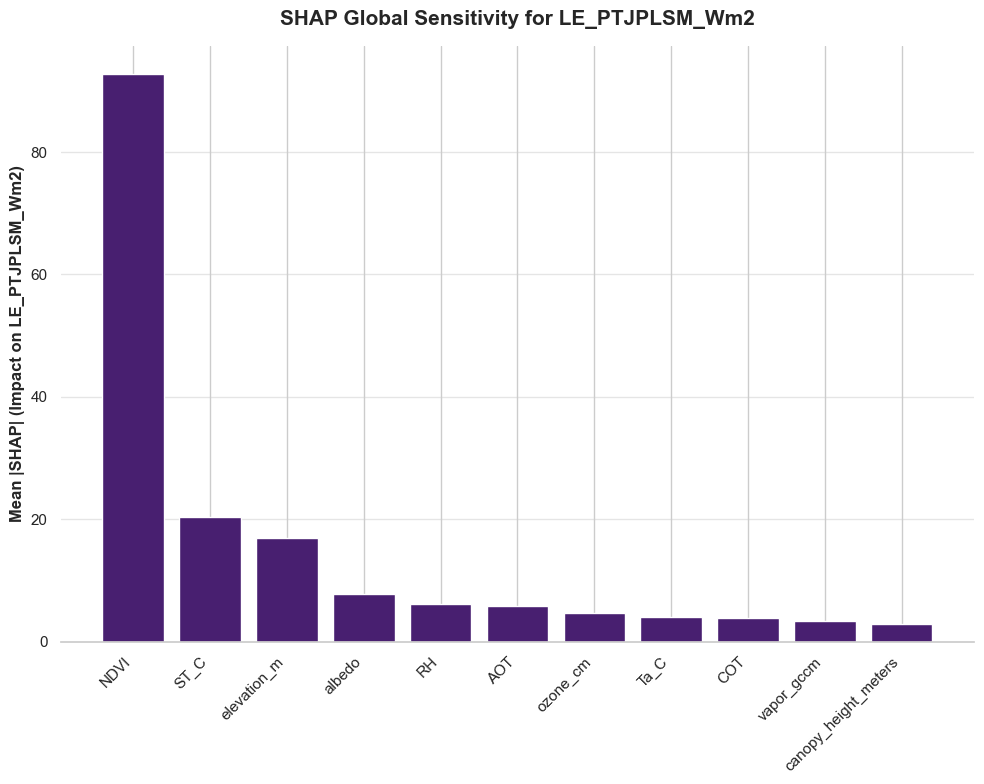

Generating SHAP beeswarm plot...


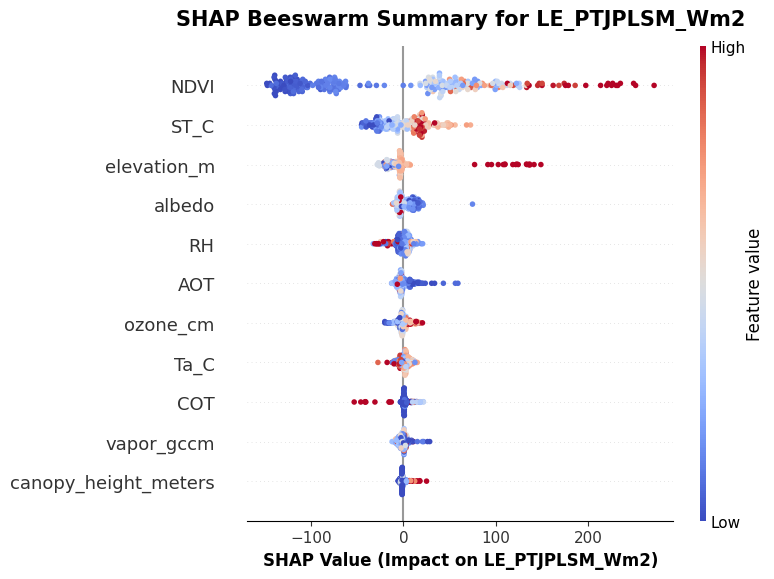


Running SHAP Sensitivity Analysis for: LE_PMJPL_Wm2

Executing forward process for 270 empirical samples...
[2026-08-10 15:11:19 INFO] starting JET table processing
[2026-08-10 15:11:19 INFO] started extracting geometry from JET input table
[2026-08-10 15:11:19 INFO] completed extracting geometry from JET input table (0.003 seconds)
[2026-08-10 15:11:19 INFO] started extracting time from JET input table
[2026-08-10 15:11:19 INFO] completed extracting time from JET input table (0.001 seconds)
[2026-08-10 15:11:19 INFO] running Forest Light Environmental Simulator
[2026-08-10 15:11:19 INFO] completed processing FLiES-ANN in 0.18 seconds
[2026-08-10 15:11:19 INFO] variable PAR_albedo min: 0.007 mean: 0.055 max: 0.193 nan: 0.00% (nan)
[2026-08-10 15:11:19 INFO] variable NIR_albedo min: 0.066 mean: 0.162 max: 0.530 nan: 0.00% (nan)
[2026-08-10 15:11:19 INFO] variable PAR_direct_Wm2 min: 7.148 mean: 269.735 max: 442.463 nan: 0.00% (nan)
[2026-08-10 15:11:19 INFO] variable SWin_FLiES_ANN min

/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halverso/.local/share/mamba/envs/JET3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

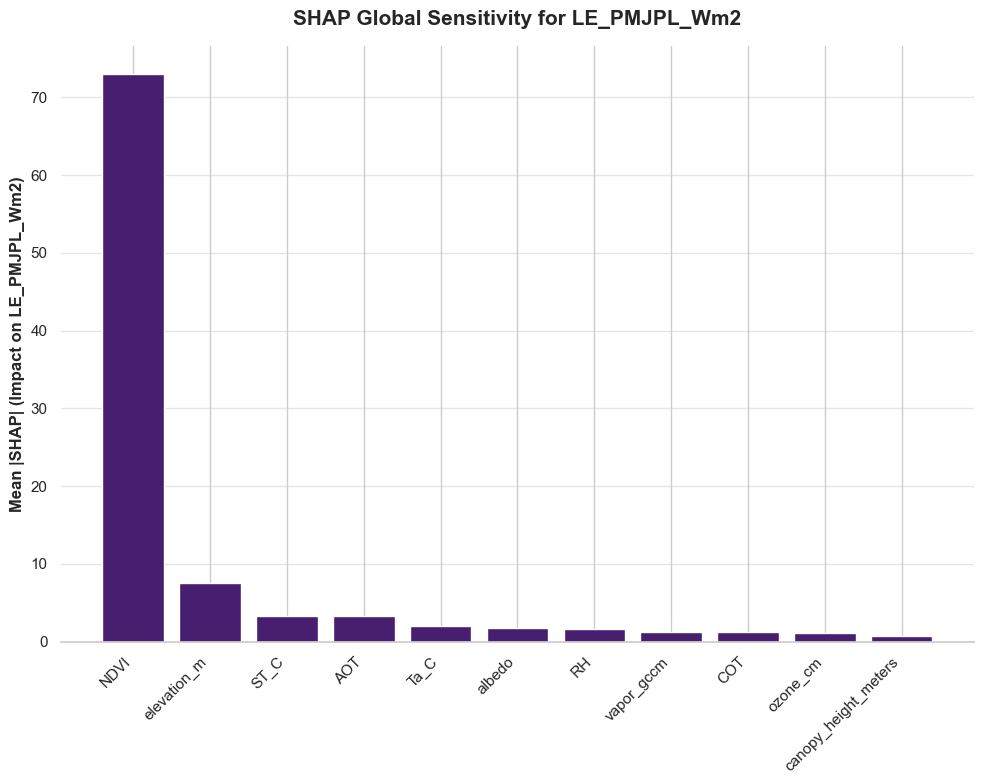

Generating SHAP beeswarm plot...


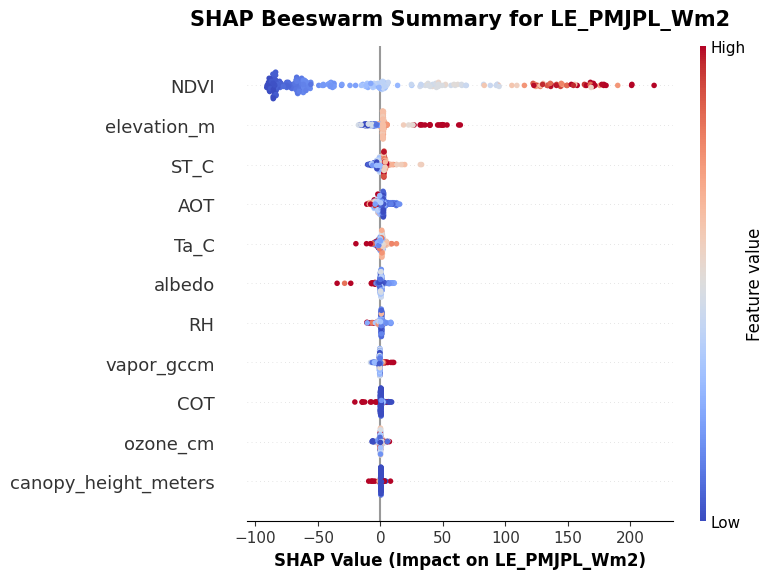

In [20]:
# Define the target outputs for the individual models
individual_targets = [
    "LE_BESS_Wm2",
    "LE_STIC_Wm2", 
    "LE_PTJPLSM_Wm2",
    "LE_PMJPL_Wm2"
]

# Loop through each model and generate the SHAP plots
for target in individual_targets:
    print(f"\n{'='*60}")
    print(f"Running SHAP Sensitivity Analysis for: {target}")
    print(f"{'='*60}\n")
    
    # 1. Run the SHAP Global Sensitivity Analysis (Bar Chart)
    explainer, shap_values, X = SHAP_sensitivity_analysis(
        input_df=input_df,
        input_variables=input_variables,
        target_output=target,
        forward_process=forward_process,
        N=1024
    )
    
    # 2. Run the SHAP Beeswarm Analysis (Scatter Plot)
    SHAP_scatter_analysis(
        explainer=explainer,
        shap_values=shap_values,
        X=X,
        target_output=target
    )